In [14]:
from escripts import eMCMC
from escripts import edata
import importlib
from escripts import eplots

In [99]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt', 
              '/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt',
             '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'McLeod+24']
sorted_data = edata.get_sorted(file_names, data_labels)

Gelli+24: $\sigma_{\rm{UV}} = -0.34 \log{M_h/M_\odot} + 4.5$

In [115]:
eMCMC.get_default_df()

,fit,value,start,lower,upper,label
alpha,True,0.6,0.6,0,4,$\alpha$
dalphadz,True,0,0.01,-0.5,0.5,$d\alpha/dz$
beta,True,-0.5,-0.5,-1,0,$\beta$
dbetadz,True,0,0.01,-0.5,0.5,$d\beta/dz$
logMc,True,12,12,9,16,$\log(M_c)$
dlogMcdz,True,0,0.01,-0.5,0.5,$d\log(M_c)/dz$
loge,True,-0.5,-1,-1,1,$\log(\epsilon_0)$
dlogedz,True,0,0.01,-0.5,0.5,$d\log(\epsilon_0)/dz$
sig,True,0,0.5,0,6,"$\sigma_{\rm{UV}, 10}$"
dsigdz,True,0,0.01,-0.5,0.5,$d\sigma_{\rm{UV}}/dz$


In [188]:
params = eMCMC.build_param_data({'sig':{'fit': False, 'value': 4.5}, 'dsigdlogM': {'fit': False, 'value': -0.34}, 
                                 'dalphadz':{'fit': False}, 'dbetadz': {'fit': False}, 'dlogMcdz': {'fit': False}, 
                                 'dlogedz': {'fit': False}, 'dsigdz': {'fit':False}
                                })

In [187]:
importlib.reload(eMCMC)

<module 'escripts.eMCMC' from '/Users/eb35267/Desktop/code/home/escripts/eMCMC.py'>

In [189]:
my_UVLF = eMCMC.UVLF(sorted_data, params, Mhpivot = 0, minsig = 0)

In [190]:
my_UVLF.run_MCMC()

/Users/eb35267/Desktop/code/home/escripts/eMCMC.py:151: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(all(self.param_data['value'][self.notfit])):
/Users/eb35267/Desktop/code/home/escripts/eMCMC.py:152: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  insert_vals = self.param_data['value'][self.notfit]
/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:84: RuntimeWarning: divide by zero encountered in divide
  xhi = np.subtract.outer(MUVcuthi, currMUV)/(np.sqrt(2) * sigmaUV)
/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:85: RuntimeWa

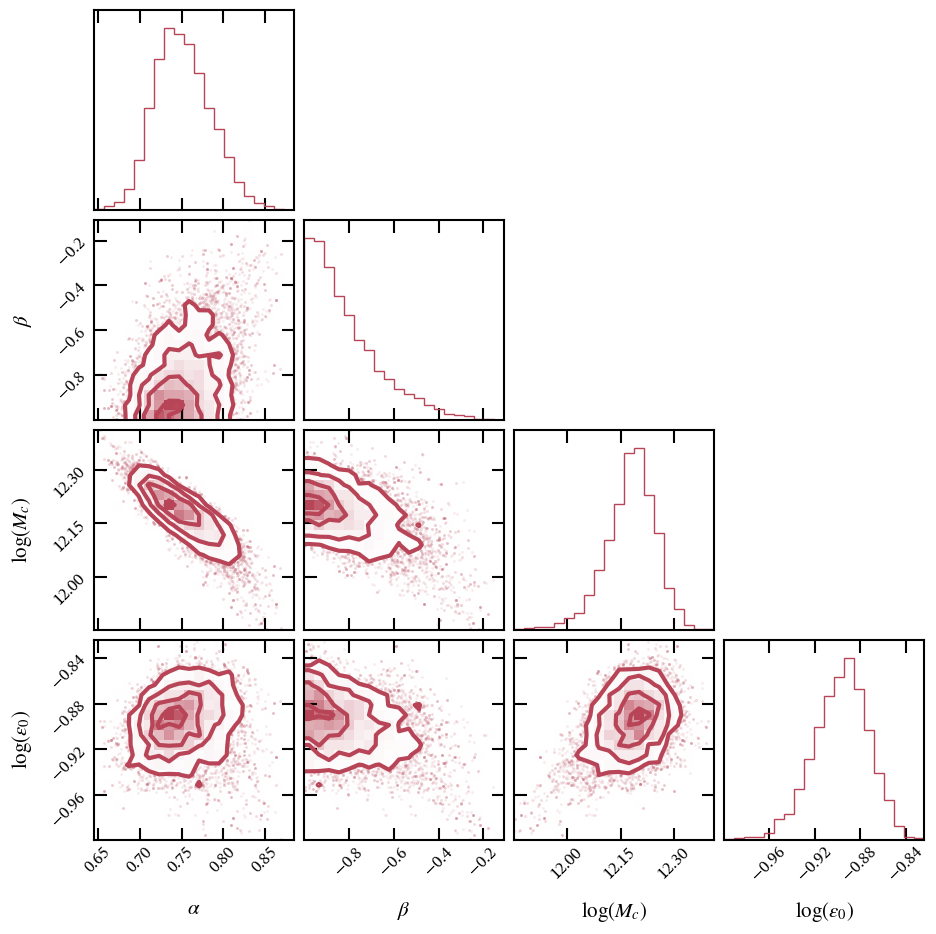

In [191]:
corner = eplots.ecorner(my_UVLF)

In [192]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

/Users/eb35267/Desktop/code/home/escripts/eMCMC.py:151: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(all(self.param_data['value'][self.notfit])):
/Users/eb35267/Desktop/code/home/escripts/eMCMC.py:152: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  insert_vals = self.param_data['value'][self.notfit]
/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:84: RuntimeWarning: divide by zero encountered in divide
  xhi = np.subtract.outer(MUVcuthi, currMUV)/(np.sqrt(2) * sigmaUV)
/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:85: RuntimeWa

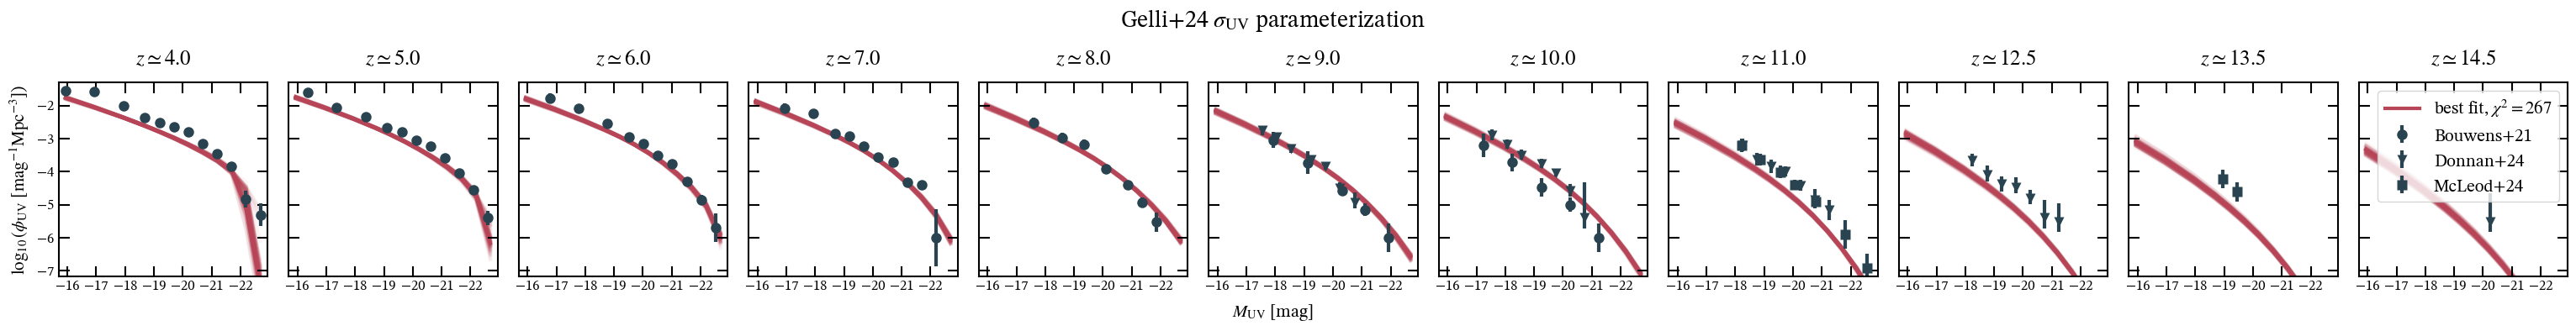

In [193]:
fig = eplots.evolving_UVLF_fit(my_UVLF, nsamples = 100, title = r'Gelli+24 $\sigma_{\rm{UV}}$ parameterization')

In [194]:
#fig.savefig('/Users/eb35267/Desktop/code/figures/min_sig_2.png', bbox_inches='tight')

In [195]:
fig.savefig('/Users/eb35267/Desktop/code/figures/gelli_24_comparison.png', bbox_inches='tight')

In [196]:
samples, best_fit, labels = my_UVLF.get_fit()

In [205]:
munoz_pw_eps = [0.84, 0.05, -1.26, 0.14, 11.83, -0.03, '-', '-', 0.59, -0.03, '-']
munoz_pw_sig = [0.69, 0.01, -1.68, 0.18, 11.93, 0, -1.11, -0.08, '-', '-', '-']

In [211]:
eMCMC.make_table([best_fit, munoz_pw_eps, munoz_pw_sig], labels, 
                 [r'MCMC with Gelli+24 $\sigma_{\rm{UV}}(M_h)$', r'Muñoz+23 piecewise $\epsilon*$', 
                  r'Muñoz+23 piecewise $\sigma_{\rm{UV}}$'])

,MCMC with Gelli+24 $\sigma_{\rm{UV}}(M_h)$,Muñoz+23 piecewise $\epsilon*$,Muñoz+23 piecewise $\sigma_{\rm{UV}}$
$\alpha$,0.74,0.84,0.69
$d\alpha/dz$,0.0,0.05,0.01
$\beta$,-1.0,-1.26,-1.68
$d\beta/dz$,0.0,0.14,0.18
$\log(M_c)$,12.21,11.83,11.93
$d\log(M_c)/dz$,0.0,-0.03,0.0
$\log(\epsilon_0)$,-0.89,-,-1.11
$d\log(\epsilon_0)/dz$,0,-,-0.08
"$\sigma_{\rm{UV}, M_c}$",4.5,0.59,-
$d\sigma_{\rm{UV}}/dz$,0,-0.03,-
